In [1]:
import requests
import pandas as pd
from dotenv import load_dotenv
import os
import time
import seaborn as sns
import matplotlib.pyplot as plt

In [75]:
# Cargar variables de entorno desde un archivo .env
load_dotenv("../.env")
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")  # Token de acceso personal de GitHub

In [76]:
# Encabezados para la solicitud a la API
headers = {
    "Authorization": f"Bearer {GITHUB_TOKEN}",
    "Content-Type": "application/json"
    }

In [77]:
# Consulta GraphQL para obtener datos de repositorios y sus contribuyentes
def get_query(cursor=None):
    cursor_str = f', after: "{cursor}"' if cursor else ""
    return f"""
    query {{
      search(query: "stars:>100", type: REPOSITORY, first: 5{cursor_str}) {{
        pageInfo {{
          endCursor
          hasNextPage
        }}
        nodes {{
          ... on Repository {{
            name
            owner {{
              login
              ... on User {{
                location
              }}
            }}
            primaryLanguage {{
              name
            }}
            stargazers {{
              totalCount
            }}
            forkCount
            # Obtener los contribuyentes principales (hasta 1 para optimizar)
            defaultBranchRef {{
              target {{
                ... on Commit {{
                  history(first: 1) {{
                    nodes {{
                      author {{
                        user {{
                          login
                          location
                        }}
                      }}
                    }}
                  }}
                }}
              }}
            }}
          }}
        }}
      }}
      rateLimit {{
        limit
        cost
        remaining
        resetAt
      }}
    }}
    """

In [78]:
# Función para hacer la solicitud a la API con reintentos
def fetch_github_data(cursor=None, retries=3, delay=5):
    url = "https://api.github.com/graphql"
    query = get_query(cursor)
    
    for attempt in range(retries):
        try:
            response = requests.post(url, json={"query": query}, headers=headers, timeout=30)
            if response.status_code == 200:
                return response.json()
            elif response.status_code == 502:
                print(f"Error 502 en intento {attempt + 1}/{retries}. Reintentando en {delay} segundos...")
                time.sleep(delay)
                continue
            else:
                raise Exception(f"Error en la solicitud: {response.status_code} - {response.text}")
        except requests.exceptions.RequestException as e:
            print(f"Error de red en intento {attempt + 1}/{retries}: {e}. Reintentando en {delay} segundos...")
            time.sleep(delay)
            continue
    raise Exception(f"Falló después de {retries} intentos: Error 502 o problema de red.")

In [79]:
# Función para procesar los datos y crear un DataFrame
def process_data(data):
    repos = data["data"]["search"]["nodes"]
    repo_data = []
    for repo in repos:
        # Obtener la ubicación del contribuyente principal
        contributor_location = "Unknown"
        if (
            repo.get("defaultBranchRef") and 
            repo["defaultBranchRef"].get("target") and 
            repo["defaultBranchRef"]["target"].get("history") and 
            repo["defaultBranchRef"]["target"]["history"].get("nodes")
        ):
            history_nodes = repo["defaultBranchRef"]["target"]["history"]["nodes"]
            if history_nodes and history_nodes[0].get("author") and history_nodes[0]["author"].get("user"):
                contributor = history_nodes[0]["author"]["user"]
                contributor_location = contributor.get("location", "Unknown")

        # Si no hay contribuyentes o la ubicación del contribuyente es Unknown, usar la ubicación del propietario
        if contributor_location == "Unknown":
            owner_location = repo["owner"].get("location") if "location" in repo["owner"] else "Unknown"
            country = owner_location
        else:
            country = contributor_location

        repo_data.append({
            "Country": country,
            "LanguageWorkedWith": repo["primaryLanguage"]["name"] if repo["primaryLanguage"] else "None",
            "RepositoryName": repo["name"],
            "Owner": repo["owner"]["login"],
            "Stars": repo["stargazers"]["totalCount"],
            "Forks": repo["forkCount"]
        })
    return repo_data, data["data"]["search"]["pageInfo"]

In [80]:
# Ejecutar y combinar los datos
def main():
    try:
        # Inicializar variables
        all_repo_data = []
        cursor = None
        target_repos = 1000
        repos_per_page = 1
        pages_needed = (target_repos // repos_per_page) + 1  # Número de páginas necesarias

        print("Iniciando recolección de datos...")

        # Bucle para paginación
        for page in range(pages_needed):
            data = fetch_github_data(cursor)
            
            # Verificar límites de la API
            rate_limit = data["data"]["rateLimit"]
            print(f"Página {page + 1}/{pages_needed} - Costo: {rate_limit['cost']} ")
            if rate_limit["remaining"] < 100:
                reset_time = rate_limit["resetAt"]
                print(f"Límite de tasa alcanzado. Esperando hasta {reset_time}...")
                time.sleep(100)

            # Procesar datos de la página actual
            repo_data, page_info = process_data(data)
            all_repo_data.extend(repo_data)

            # Verificar si hemos alcanzado el objetivo
            if len(all_repo_data) >= target_repos:
                all_repo_data = all_repo_data[:target_repos]  # Limitar a target_repos
                break

            # Actualizar cursor para la siguiente página
            if page_info["hasNextPage"]:
                cursor = page_info["endCursor"]
            else:
                print("No hay más páginas disponibles.")
                break

            # Pausa para evitar exceder el límite de tasa
            time.sleep(2)

        # Crear DataFrame final
        repo_df = pd.DataFrame(all_repo_data)
        
        # Mostrar información
        print("\nDatos recolectados:")
        print(repo_df.head())
        print(f"\nTotal de repositorios recolectados: {len(repo_df)}")
        
        # Guardar en CSV
        repo_df.to_csv("../data/data_api.csv", index=False)
        print("Datos guardados en 'data_api.csv'")

        # Retornar el DataFrame
        return repo_df

    except Exception as e:
        print(f"Error: {e}")
        return None  # En caso de error, retorna None

# Llamar a la función y asignar el resultado a df
df = main()


Iniciando recolección de datos...
Página 1/1001 - Costo: 1 
Página 2/1001 - Costo: 1 
Página 3/1001 - Costo: 1 
Página 4/1001 - Costo: 1 
Página 5/1001 - Costo: 1 
Página 6/1001 - Costo: 1 
Página 7/1001 - Costo: 1 
Página 8/1001 - Costo: 1 
Página 9/1001 - Costo: 1 
Página 10/1001 - Costo: 1 
Página 11/1001 - Costo: 1 
Página 12/1001 - Costo: 1 
Página 13/1001 - Costo: 1 
Página 14/1001 - Costo: 1 
Página 15/1001 - Costo: 1 
Página 16/1001 - Costo: 1 
Página 17/1001 - Costo: 1 
Página 18/1001 - Costo: 1 
Página 19/1001 - Costo: 1 
Página 20/1001 - Costo: 1 
Página 21/1001 - Costo: 1 
Página 22/1001 - Costo: 1 
Página 23/1001 - Costo: 1 
Página 24/1001 - Costo: 1 
Página 25/1001 - Costo: 1 
Página 26/1001 - Costo: 1 
Página 27/1001 - Costo: 1 
Página 28/1001 - Costo: 1 
Página 29/1001 - Costo: 1 
Página 30/1001 - Costo: 1 
Página 31/1001 - Costo: 1 
Página 32/1001 - Costo: 1 
Página 33/1001 - Costo: 1 
Página 34/1001 - Costo: 1 
Página 35/1001 - Costo: 1 
Página 36/1001 - Costo: 1 
Pág

In [81]:
df.head(10)

,Country,LanguageWorkedWith,RepositoryName,Owner,Stars,Forks
0,Internet,TypeScript,freeCodeCamp,freeCodeCamp,415675,39692
1,San Francisco,Markdown,build-your-own-x,codecrafters-io,368983,34285
2,Norway,None,awesome,sindresorhus,355012,28872
3,None,HTML,free-programming-books,EbookFoundation,354541,63158
4,None,Python,public-apis,public-apis,335150,35452
5,None,None,coding-interview-university,jwasham,314053,78319
6,United Kingdom,TypeScript,developer-roadmap,kamranahmedse,313320,40768
7,bash,Python,system-design-primer,donnemartin,295723,49166
8,None,None,996.ICU,996icu,270488,21103
9,Taiwan,Python,awesome-python,vinta,239581,25507


In [1]:
df.info()

NameError: name 'df' is not defined

In [80]:
df.isnull().sum()

Country               339
LanguageWorkedWith    104
RepositoryName          0
Owner                   0
Stars                   0
Forks                   0
dtype: int64

In [81]:
df.describe()

,Stars,Forks
count,1000.00000,1000.000000
mean,50646.29300,8332.558000
std,40443.28839,10322.386056
min,26187.00000,379.000000
25%,30268.75000,2860.000000
50%,37406.50000,5465.000000
75%,54050.75000,9394.750000
max,415520.00000,86367.000000


In [82]:
df.nunique()

Country               390
LanguageWorkedWith     46
RepositoryName        988
Owner                 870
Stars                 990
Forks                 954
dtype: int64

In [83]:
df['LanguageWorkedWith'].value_counts().head(10)


LanguageWorkedWith
Python              180
TypeScript          146
JavaScript          144
Go                   72
Java                 51
C++                  50
Rust                 41
C                    25
Jupyter Notebook     21
Shell                21
Name: count, dtype: int64

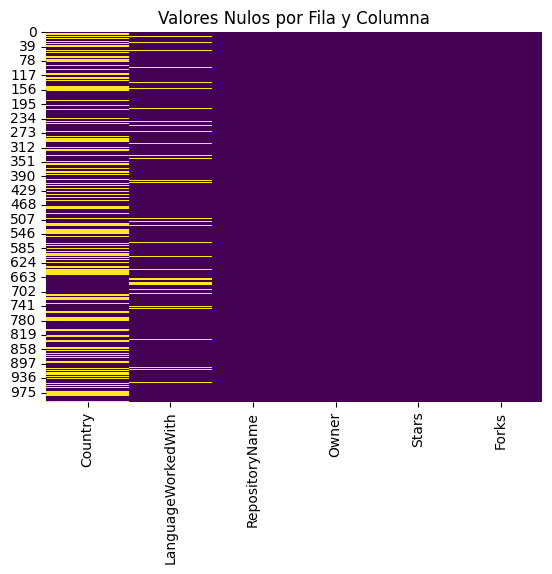

In [88]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Valores Nulos por Fila y Columna")
plt.show()

In [92]:
df['Country'].value_counts().head(10)

Country
Unknown            14
San Francisco      11
Shanghai, China    10
Seattle, WA         9
Shanghai            8
Paris               8
India               8
China               8
Paris, France       8
Singapore           8
Name: count, dtype: int64

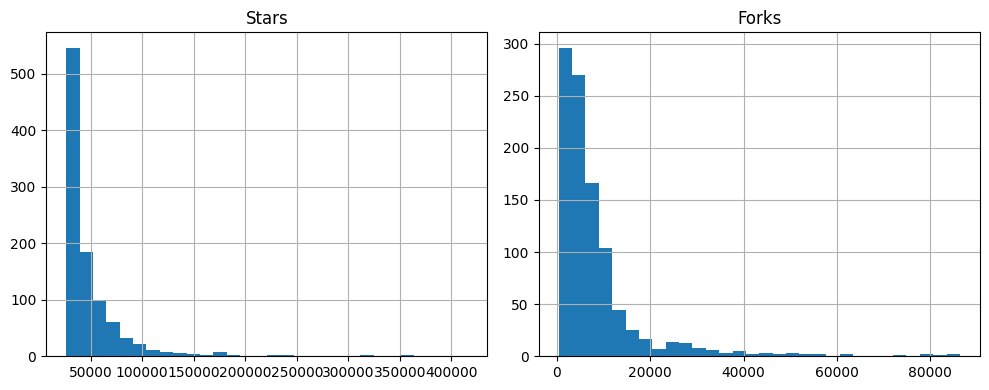

In [ ]:
# Histograma de 'Stars'
plt.figure(figsize=(10, 5))
sns.histplot(df['Stars'], bins=30, kde=True)
plt.title('Distribución de Estrellas')
plt.xlabel('Estrellas')
plt.ylabel('Frecuencia')
plt.show()

# Histograma de 'Forks'
plt.figure(figsize=(10, 5))
sns.histplot(df['Forks'], bins=30, kde=True)
plt.title('Distribución de Forks')
plt.xlabel('Forks')
plt.ylabel('Frecuencia')
plt.show()

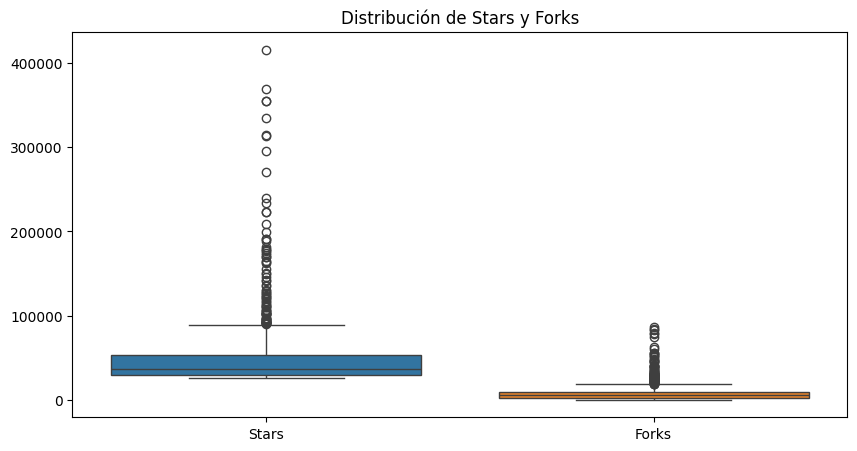

In [95]:
# Boxplot para detectar outliers
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Stars', 'Forks']])
plt.title('Distribución de Stars y Forks')
plt.show()

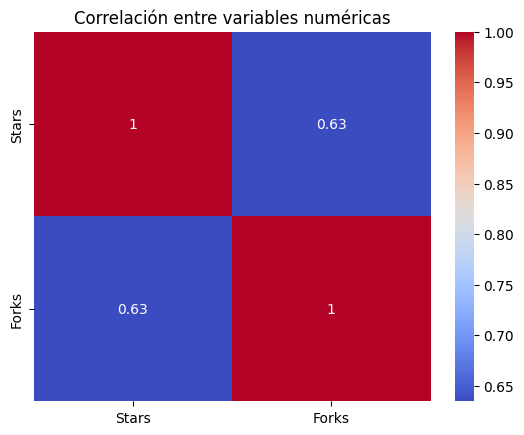

In [97]:
sns.heatmap(df[['Stars', 'Forks']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlación entre variables numéricas")
plt.show()


In [98]:
country_mapping = {
    # Ciudades/estados de Estados Unidos
    'SAN FRANCISCO': 'United States',
    'NEW YORK': 'United States',
    'RENTON, WASHINGTON': 'United States',
    'SEATTLE, WA': 'United States',
    'PORTLAND, OR': 'United States',
    'PHILADELPHIA USA': 'United States',
    'HAWAII': 'United States',
    'NEW ORLEANS': 'United States',
    'BOSTON': 'United States',
    'EST. AKRON': 'United States',
    'ST. LOUIS, MO': 'United States',
    'HILLSBOROUGH, CA': 'United States',
    'SAN DIEGO, CA': 'United States',
    'MASSACHUSETTS, USA': 'United States',
    'MENLO PARK': 'United States',
    'MIAMI, FL': 'United States',
    'BAY AREA': 'United States',
    'CAMBRIDGE, MA': 'United States',
    'SF BAY AREA': 'United States',
    'OAKLAND, CALIFORNIA': 'United States',
    'DENVER, CO': 'United States',
    'LOS ANGELES, CA': 'United States',
    'SANTA CLARA, CA': 'United States',
    'SAN JOSE, CA': 'United States',
    'BERKELEY, CA': 'United States',
    'PITTSBURGH, PA': 'United States',
    'CHARLOTTESVILLE, VA': 'United States',
    'CALIFORNIA, US': 'United States',
    'UNITED STATES': 'United States',
    'NORTH CAROLINA, US': 'United States',
    'HOUSTON': 'United States',
    'JACKSONVILLE, FL': 'United States',
    'MARLBOROUGH, MA': 'United States',
    'GREENBELT, MD': 'United States',
    'SUMMIT PARK, UT': 'United States',
    'NYC': 'United States',
    'ENDICOTT, NY': 'United States',
    'ANN ARBOR, MI, USA': 'United States',
    'BUFFALO NY': 'United States',
    'SEATTLE': 'United States',
    'VIRGINIA, USA': 'United States',
    'DE': 'United States',  # Supongo que "DE" se refiere a Delaware
    'BALTIMORE, MD': 'United States',
    'LAFAYETTE, LA': 'United States',
    'COLORADO': 'United States',
    'PORTLAND, OR, USA': 'United States',
    'LONGMONT, COLORADO, USA': 'United States',
    'AUSTIN, TX': 'United States',
    'PALO ALTO, CALIFORNIA, USA': 'United States',
    'WASHINGTON': 'United States',
    'WASHINGTON, DC': 'United States',
    'BROOKLYN, NY': 'United States',

    # Ciudades/estados de China
    'GUANGZHOU, CHINA': 'China',
    'CHENGDU SICHUAN, CHINA': 'China',
    'WUHAN, HUBEI': 'China',
    'BEIJING, CHINA': 'China',
    'HANGZHOU CHINA': 'China',
    'SHANGHAI': 'China',
    'SHENZHEN, CHINA': 'China',
    'WUXI,CHINA': 'China',
    'SUZHOU, CHINA': 'China',
    'CHINA': 'China',
    'CHENGDU SICHUAN CHINA': 'China',
    'BEIJING': 'China',
    'SHENZHEN': 'China',
    'HANGZHOU, CHINA': 'China',
    'ZHENGZHOU, CHINA': 'China',
    'CHONGQING, CHINA': 'China',
    'HEFEI, ANHUI, CHINA': 'China',
    'XI\'AN, CHINA': 'China',
    'TIANJIN': 'China',
    'HONG KONG, CHINA': 'China',
    'TAIYUAN,SHANXI,CHINA': 'China',
    'WUHAN. CHINA': 'China',

    # Ciudades/estados de India
    'BHAVNAGAR, GUJARAT': 'India',
    'INDIA': 'India',
    'PUNE, INDIA': 'India',
    'KERALA, INDIA': 'India',
    'BANGALORE, INDIA': 'India',
    'MUMBAI': 'India',
    'NEW DELHI , INDIA': 'India',
    'GUJARAT, INDIA': 'India',
    'HYDERABAD': 'India',
    'COIMBATORE': 'India',
    'BANGALORE': 'India',

    # Ciudades/estados de Italia
    'BOLOGNA, ITALY': 'Italy',
    'ITALY': 'Italy',
    'CHIOGGIA, ITALY': 'Italy',
    'PROVINCIA DI VARESE, ITALY': 'Italy',

    # Ciudades/estados de Reino Unido
    'LONDON, UK': 'United Kingdom',
    'LONDON, UNITED KINGDOM': 'United Kingdom',
    'LONDON': 'United Kingdom',
    'BRIGHTON, UK': 'United Kingdom',
    'EDINBURGH, UK': 'United Kingdom',
    'DEVON, UK': 'United Kingdom',
    'GLASGOW, UK': 'United Kingdom',
    'CAMBRIDGE, UK': 'United Kingdom',
    'CARDIFF, UNITIED KINGDOM': 'United Kingdom',
    'UK': 'United Kingdom',
    'UNITED KINGDOM': 'United Kingdom',

    # Ciudades/estados de Francia
    'PARIS': 'France',
    'PARIS, FRANCE': 'France',
    'FRANCE': 'France',
    'LILLE, FRANCE': 'France',
    'UNIVERSITÉ PARIS-SACLAY': 'France',
    'FRANCE, BORDEAUX': 'France',
    'FRANCE - LYON': 'France',
    'VALBONNE, FRANCE': 'France',
    'GRENOBLE - FRANCE': 'France',
    'LYON, FRANCE': 'France',

    # Ciudades/estados de Alemania
    'DRESDEN, GERMANY': 'Germany',
    'BERLIN, GERMANY': 'Germany',
    'DÜSSELDORF, DE': 'Germany',
    'NORTH RHINE-WESTPHALIA, GERMANY': 'Germany',
    'GERMANY, MAGDEBURG': 'Germany',
    'BREMEN': 'Germany',
    'HAMBURG, GERMANY, EARTH (SOL)': 'Germany',
    'HAMBURG': 'Germany',
    'ERLANGEN, GERMANY': 'Germany',
    'KARLSRUHE, GERMANY': 'Germany',
    'MUNICH, GERMANY': 'Germany',
    'FRANKFURT/MAIN (GERMANY)': 'Germany',
    'GERMANY': 'Germany',

    # Ciudades/estados de Canadá
    'TORONTO, CANADA': 'Canada',
    'VANCOUVER, BC': 'Canada',
    'CANADA / QUÉBEC': 'Canada',
    'TORONTO, ON': 'Canada',
    'BURLINGTON, CANADA': 'Canada',
    'KINGSTON, ONTARIO, CANADA': 'Canada',
    'MONTREAL, QUEBEC': 'Canada',
    'WATERLOO, CANADA': 'Canada',
    'VANCOUVER, CANADA': 'Canada',
    'CANADA': 'Canada',

    # Ciudades/estados de Japón
    'JAPAN': 'Japan',
    'TOKYO, JAPAN': 'Japan',
    'TORISHIRO JIMA': 'Japan',
    'TOKYO': 'Japan',

    # Ciudades/estados de España
    'BARCELONA, SPAIN': 'Spain',
    'GETAFE, SPAIN': 'Spain',
    'MADRID - SPAIN': 'Spain',
    'BUILDING SOFTWARE WITH  ♥ FROM GALICIA (SPAIN) TO THE WORLD.': 'Spain',
    'MADRID, SPAIN': 'Spain',
    'MURCIA': 'Spain',

    # Ciudades/estados de Países Bajos
    'AMSTERDAM': 'Netherlands',
    'DELFT, NL': 'Netherlands',
    'THE NETHERLANDS': 'Netherlands',
    'NETHERLANDS': 'Netherlands',
    'AMSTERDAM, NETHERLANDS': 'Netherlands',

    # Ciudades/estados de Suecia
    'STOCKHOLM, SWEDEN': 'Sweden',
    'SWEDEN': 'Sweden',
    'MALMÖ, SWEDEN': 'Sweden',
    'STOCKHOLM, SE': 'Sweden',

    # Ciudades/estados de Suiza
    'SWITZERLAND': 'Switzerland',
    'ZÜRICH, SCHWEIZ': 'Switzerland',
    'ZÜRICH, ZURICH, SWITZERLAND': 'Switzerland',
    'ZURICH, SWITZERLAND': 'Switzerland',

    # Ciudades/estados de Brasil
    'FRANCA, SÃO PAULO, BRAZIL': 'Brazil',
    'RIBEIRÃO PIRES - SP': 'Brazil',
    'BRAZIL': 'Brazil',

    # Ciudades/estados de Polonia
    'POLAND': 'Poland',
    'TORUŃ, POLAND': 'Poland',
    'WROCŁAW, POLAND': 'Poland',
    'WARSAW, POLAND': 'Poland',
    'POZNAŃ': 'Poland',

    # Ciudades/estados de Australia
    'MELBOURNE, AUSTRALIA': 'Australia',
    'SYDNEY, AUSTRALIA': 'Australia',
    'SYDNEY': 'Australia',
    'MELBOURNE, AU': 'Australia',

    # Ciudades/estados de Rusia
    'SAINT-PETERSBURG, RUSSIA': 'Russia',
    'ISRAEL, TEL-AVIV /// RUSSIA, SAINT PETERSBURG/KIROV': 'Russia',  # Priorizo el último país mencionado

    # Ciudades/estados de Israel
    'ISRAEL': 'Israel',
    'TEL AVIV, ISRAEL': 'Israel',

    # Ciudades/estados de Ucrania
    'UKRAINE, KYIV': 'Ukraine',
    'KYIV, UKRAINE': 'Ukraine',

    # Ciudades/estados de Turquía
    'ISTANBUL, TURKEY': 'Turkey',
    'TURKEY': 'Turkey',

    # Ciudades/estados de Grecia
    'ATHENS, GREECE': 'Greece',

    # Ciudades/estados de Hungría
    'BUDAPEST, HUNGARY': 'Hungary',
    'BUDAPEST 🇭🇺': 'Hungary',

    # Ciudades/estados de Sudáfrica
    'GEORGE. SOUTH AFRICA': 'South Africa',

    # Ciudades/estados de Finlandia
    'FINLAND': 'Finland',

    # Ciudades/estados de Noruega
    'NORWAY': 'Norway',

    # Ciudades/estados de Taiwán
    'TAIWAN': 'Taiwan',
    'TAICHUNG, TAIWAN': 'Taiwan',
    'TAIWAN, R.O.C': 'Taiwan',

    # Ciudades/estados de Singapur
    'SINGAPORE': 'Singapore',

    # Ciudades/estados de Kenia
    'KENYA': 'Kenya',
    'NAIROBI': 'Kenya',

    # Ciudades/estados de Dinamarca
    'SKALS, DENMARK': 'Denmark',
    'ELSINORE': 'Denmark',
    'DENMARK': 'Denmark',

    # Ciudades/estados de Bélgica
    'GHENT, BELGIUM': 'Belgium',
    'BELGIUM': 'Belgium',

    # Ciudades/estados de Rumania
    'ROMANIA': 'Romania',

    # Ciudades/estados de Malta
    'MALTA': 'Malta',

    # Ciudades/estados de Egipto
    'ASSIUT': 'Egypt',
    'EGYPT': 'Egypt',

    # Ciudades/estados de Nueva Zelanda
    'PARAPARAUMU, NEW ZEALAND': 'New Zealand',
    'AUCKLAND': 'New Zealand',

    # Ciudades/estados de Austria
    'VIENNA, AUSTRIA': 'Austria',
    'AUSTRIA': 'Austria',

    # Ciudades/estados de Malasia
    'MALAYSIA': 'Malaysia',

    # Ciudades/estados de Irán
    'MASHHAD, IRAN': 'Iran',

    # Ciudades/estados de Corea del Sur
    'SEOUL': 'South Korea',
    'SOUTH KOREA': 'South Korea',

    # Ciudades/estados de Lituania
    'LITHUANIA': 'Lithuania',

    # Ciudades/estados de Estonia
    'TALLINN': 'Estonia',

    # Ciudades/estados de Bosnia y Herzegovina
    'BOSNIA AND HERZEGOVINA': 'Bosnia and Herzegovina',

    # Ciudades/estados de Argentina
    'ARGENTINA': 'Argentina',

    # Ciudades/estados de Kazajistán
    'KAZAKHSTAN, ASTANA': 'Kazakhstan',

    # Ciudades/estados de Tailandia
    'BANGKOK, THAILAND': 'Thailand',

    # Ciudades/estados de Irlanda
    'DUBLIN, IRELAND': 'Ireland',

    # Ciudades/estados de Portugal
    'PORTUGAL': 'Portugal',

    # Ciudades/estados de Bangladesh
    'BANGLADESH': 'Bangladesh',
}

# Lista de países válidos para validar el mapeo
valid_countries = [
    'United States', 'China', 'India', 'Italy', 'United Kingdom', 'France', 'Germany', 'Canada',
    'Japan', 'Spain', 'Netherlands', 'Sweden', 'Switzerland', 'Brazil', 'Poland', 'Australia',
    'Russia', 'Israel', 'Ukraine', 'Turkey', 'Greece', 'Hungary', 'South Africa', 'Finland',
    'Norway', 'Taiwan', 'Singapore', 'Kenya', 'Denmark', 'Belgium', 'Romania', 'Malta', 'Egypt',
    'New Zealand', 'Austria', 'Malaysia', 'Iran', 'South Korea', 'Lithuania', 'Estonia',
    'Bosnia and Herzegovina', 'Argentina', 'Kazakhstan', 'Thailand', 'Ireland', 'Portugal',
    'Bangladesh'
]

In [99]:
# Función para normalizar los valores de la columna 'Country'
def normalize_country(value):
    if pd.isna(value) or value.strip() == "":
        return "Other"
    
    # Convertir a mayúsculas y eliminar espacios para la comparación
    value_normalized = value.upper().replace(',', '').replace('  ', ' ').strip()
    
    # Buscar en el diccionario de mapeo
    for key in country_mapping:
        if key in value_normalized:
            return country_mapping[key]
    
    # Si el valor ya es un país válido, usarlo directamente
    value_cleaned = value.strip().title()
    if value_cleaned in valid_countries:
        return value_cleaned
    
    # Si no se puede mapear, etiquetarlo como "Other"
    return "Other"

In [100]:
# Aplicar la normalización a la columna 'Country'
df['Country'] = df['Country'].apply(normalize_country)

In [114]:
df['Country'].value_counts().head(10)

Country
Other             550
United States     104
China              94
United Kingdom     37
France             29
Germany            24
India              19
Japan              13
Netherlands        12
Canada             12
Name: count, dtype: int64

In [109]:
# Contar repositorios por país
country_counts = df['Country'].value_counts()

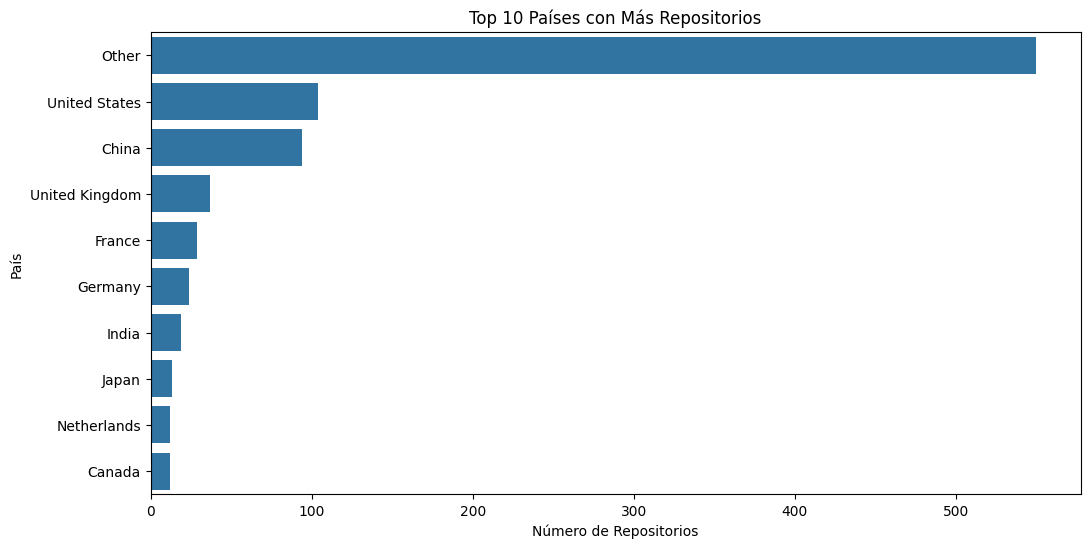

In [110]:
# Visualizar la distribución
plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.values[:10], y=country_counts.index[:10])
plt.title('Top 10 Países con Más Repositorios')
plt.xlabel('Número de Repositorios')
plt.ylabel('País')
plt.show()

In [111]:
# Promedio de estrellas y forks por país
country_stats = df.groupby('Country')[['Stars', 'Forks']].mean().sort_values(by='Stars', ascending=False)

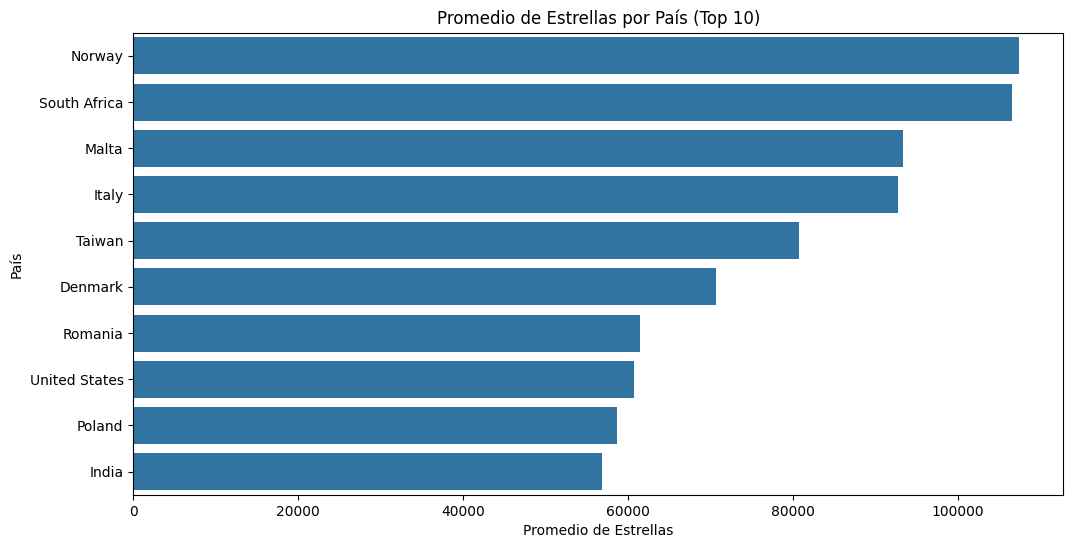

In [112]:
# Visualizar promedio de estrellas por país
plt.figure(figsize=(12, 6))
sns.barplot(x=country_stats['Stars'][:10], y=country_stats.index[:10])
plt.title('Promedio de Estrellas por País (Top 10)')
plt.xlabel('Promedio de Estrellas')
plt.ylabel('País')
plt.show()

In [ ]:
count = df["Country"].str.contains("Norway", case=False, na=False).sum()
print("repositorios de Norway:",count)

count = df["Country"].str.contains("South Africa", case=False, na=False).sum()
print("repositorios de South Africa:",count)

count = df["Country"].str.contains("Malta", case=False, na=False).sum()
print("repositorios de Malta:",count)

count = df["Country"].str.contains("italy", case=False, na=False).sum()
print("repositorios de italy:",count)

In [106]:
# Imputar valores nulos en 'LanguageWORKEDwith'
df['LanguageWorkedWith'] = df['LanguageWorkedWith'].fillna('Not Specified')

In [2]:
df['LanguageWorkedWith'].isnull().sum()

NameError: name 'df' is not defined

In [ ]:
# Dividir los lenguajes (suponiendo que están separados por ';')
df['Languages'] = df['LanguageWorkedWith'].str.split(';')

In [ ]:
# Crear una lista de todos los lenguajes (puede haber múltiples lenguajes por repositorio)
all_languages = df['Languages'].explode().dropna()

# Contar la frecuencia de cada lenguaje
language_counts = all_languages.value_counts()

In [ ]:
# Visualizar
plt.figure(figsize=(12, 6))
sns.barplot(x=language_counts.values[:10], y=language_counts.index[:10])
plt.title('Top 10 Lenguajes Más Utilizados')
plt.xlabel('Número de Repositorios')
plt.ylabel('Lenguaje')
plt.show()

In [ ]:
# Promedio de estrellas por lenguaje
language_stats = df.explode('Languages').groupby('Languages')[['Stars', 'Forks']].mean().sort_values(by='Stars', ascending=False)
print("Promedio de estrellas y forks por lenguaje (Top 10 por estrellas):")
print(language_stats.head(10))

# Visualizar
plt.figure(figsize=(12, 6))
sns.barplot(x=language_stats['Stars'][:10], y=language_stats.index[:10])
plt.title('Promedio de Estrellas por Lenguaje (Top 10)')
plt.xlabel('Promedio de Estrellas')
plt.ylabel('Lenguaje')
plt.show()

In [ ]:
# Repositorios con más estrellas
top_repos_stars = df[['RepositoryName', 'Owner', 'Stars', 'Forks']].sort_values(by='Stars', ascending=False).head(10)

# Visualizar
plt.figure(figsize=(12, 6))
sns.barplot(x='Stars', y='RepositoryName', hue='Owner', data=top_repos_stars)
plt.title('Top 10 Repositorios por Estrellas')
plt.xlabel('Estrellas')
plt.ylabel('Repositorio')
plt.show()

In [ ]:
# Repositorios con más estrellas
top_repos_stars = df[['RepositoryName', 'Owner', 'Stars', 'Forks']].sort_values(by='Stars', ascending=False).head(10)

# Visualizar
plt.figure(figsize=(12, 6))
sns.barplot(x='Stars', y='RepositoryName', hue='Owner', data=top_repos_stars)
plt.title('Top 10 Repositorios por Estrellas')
plt.xlabel('Estrellas')
plt.ylabel('Repositorio')
plt.show()

In [ ]:
# Contar repositorios por propietario
owner_counts = df['Owner'].value_counts()

# Visualizar
plt.figure(figsize=(12, 6))
sns.barplot(x=owner_counts.values[:10], y=owner_counts.index[:10])
plt.title('Top 10 Propietarios con Más Repositorios')
plt.xlabel('Número de Repositorios')
plt.ylabel('Propietario')
plt.show()

In [ ]:
# Promedio de estrellas por propietario
owner_stats = df.groupby('Owner')[['Stars', 'Forks']].mean().sort_values(by='Stars', ascending=False)
print("Promedio de estrellas y forks por propietario (Top 10 por estrellas):")
print(owner_stats.head(10))

In [ ]:
# Lenguajes por país
languages_by_country = df.explode('Languages').groupby('Country')['Languages'].value_counts()
print("Lenguajes más utilizados por país:")
print(languages_by_country.groupby('Country').head(3))  # Top 3 lenguajes por país

In [ ]:
# Promedio de estrellas por país y lenguaje
country_language_stats = df.explode('Languages').groupby(['Country', 'Languages'])['Stars'].mean().reset_index()
top_stats = country_language_stats.sort_values(by='Stars', ascending=False).head(10)
print("Top 10 combinaciones de país y lenguaje por promedio de estrellas:")
print(top_stats)

# Visualizar
plt.figure(figsize=(12, 6))
sns.barplot(x='Stars', y='Country', hue='Languages', data=top_stats)
plt.title('Top 10 Combinaciones de País y Lenguaje por Promedio de Estrellas')
plt.xlabel('Promedio de Estrellas')
plt.ylabel('País')
plt.show()

In [ ]:
# Repositorios con muchas estrellas pero pocos forks
high_stars_low_forks = df[(df['Stars'] > df['Stars'].quantile(0.75)) & (df['Forks'] < df['Forks'].quantile(0.25))]
print("Repositorios con muchas estrellas pero pocos forks:")
print(high_stars_low_forks[['RepositoryName', 'Owner', 'Stars', 'Forks']].head())